## Implementación de CNN con CIFAR-10

### 1. Cargar y Preprocesar el Dataset CIFAR-10

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Cargar el dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalizar las imágenes a un rango de [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convertir las etiquetas a one-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(f"Shape de x_train: {x_train.shape}")
print(f"Shape de y_train: {y_train.shape}")
print(f"Shape de x_test: {x_test.shape}")
print(f"Shape de y_test: {y_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Shape de x_train: (50000, 32, 32, 3)
Shape de y_train: (50000, 10)
Shape de x_test: (10000, 32, 32, 3)
Shape de y_test: (10000, 10)


### 2. Definir la Arquitectura de la CNN

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Definir el modelo CNN
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3), padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

### 3. Compilar el Modelo

In [3]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

### 4. Entrenar el Modelo

In [4]:
history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=64,
                    validation_data=(x_test, y_test))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 131s 157ms/step - accuracy: 0.4056 - loss: 1.6260 - val_accuracy: 0.5134 - val_loss: 1.3270
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 116s 148ms/step - accuracy: 0.5572 - loss: 1.2532 - val_accuracy: 0.6370 - val_loss: 1.0244
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 116s 149ms/step - accuracy: 0.6290 - loss: 1.0638 - val_accuracy: 0.6859 - val_loss: 0.9105
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 115s 147ms/step - accuracy: 0.6693 - loss: 0.9484 - val_accuracy: 0.6856 - val_loss: 0.9139
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 116s 149ms/step - accuracy: 0.7001 - loss: 0.8617 - val_accuracy: 0.7134 - val_loss: 0.8307
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 119s 153ms/step - accuracy: 0.7242 - loss: 0.7972 - val_accuracy: 0.7272 - val_loss: 0.8017
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 116s 149ms/step - accuracy: 0.7428 - loss: 0.7351 - val_accuracy: 0.7364 - val_loss: 0.7642
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 141s 147ms/step - accuracy: 0.7594 -

### 5. Evaluar el Modelo

In [5]:
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Precisión en el conjunto de prueba: {accuracy:.4f}")
print(f"Pérdida en el conjunto de prueba: {loss:.4f}")

Precisión en el conjunto de prueba: 0.7468
Pérdida en el conjunto de prueba: 0.7487


### 6. Visualizar el historial de entrenamiento

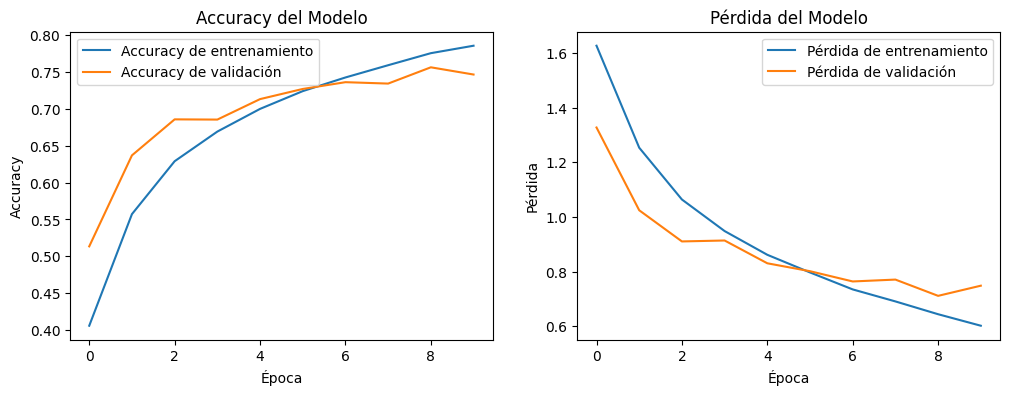

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Accuracy de entrenamiento')
plt.plot(history.history['val_accuracy'], label='Accuracy de validación')
plt.title('Accuracy del Modelo')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.title('Pérdida del Modelo')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

plt.show()

### 7. Guardar y Cargar el Modelo

Guardaremos el modelo entrenado en formato `.keras`, que es el formato estándar y recomendado para modelos de TensorFlow/Keras, ya que conserva la arquitectura, pesos, configuración del optimizador y estado de entrenamiento. Es preferible a `.pkl` para estos modelos.

In [7]:
model.save('cifar10_cnn_model.keras')
print("Modelo guardado exitosamente como 'cifar10_cnn_model.keras'")

Modelo guardado exitosamente como 'cifar10_cnn_model.keras'


Ahora, cargaremos el modelo y haremos una predicción con una imagen de ejemplo del conjunto de prueba para verificar su funcionamiento.

Modelo cargado exitosamente.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


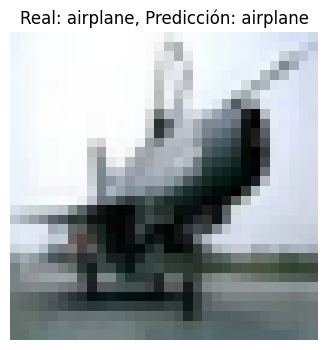

Predicciones completas para la imagen seleccionada: [6.2329209e-01 4.7089936e-05 1.1216474e-01 3.7494460e-03 8.0902046e-03
 5.9660053e-04 3.4721001e-04 1.6246501e-03 2.4402325e-01 6.0646678e-03]
Clase predicha (índice): 0
Clase predicha (nombre): airplane
Clase real (nombre): airplane


In [8]:
import numpy as np
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Cargar el modelo guardado
loaded_model = load_model('cifar10_cnn_model.keras')
print("Modelo cargado exitosamente.")

# Definir las clases de CIFAR-10
cifar10_class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Seleccionar una imagen aleatoria del conjunto de prueba
# Usamos el x_test original (no one-hot encoded) para obtener el índice de clase real.
# Para la visualización, usaremos la imagen normalizada x_test

# Cargar el dataset CIFAR-10 nuevamente para obtener las etiquetas originales para la verificación
(x_train_orig, y_train_orig), (x_test_orig, y_test_orig) = cifar10.load_data()

# Seleccionar un índice aleatorio
idx = np.random.randint(0, len(x_test))

# Obtener la imagen y su etiqueta real
sample_image = x_test[idx]
actual_label_idx = y_test_orig[idx][0]
actual_label_name = cifar10_class_names[actual_label_idx]

# Preparar la imagen para la predicción (añadir una dimensión para el batch)
image_for_prediction = np.expand_dims(sample_image, axis=0)

# Realizar la predicción
predictions = loaded_model.predict(image_for_prediction)
predicted_class_idx = np.argmax(predictions)
predicted_class_name = cifar10_class_names[predicted_class_idx]

# Mostrar la imagen y la predicción
plt.figure(figsize=(4, 4))
plt.imshow(sample_image)
plt.title(f"Real: {actual_label_name}, Predicción: {predicted_class_name}")
plt.axis('off')
plt.show()

print(f"Predicciones completas para la imagen seleccionada: {predictions[0]}")
print(f"Clase predicha (índice): {predicted_class_idx}")
print(f"Clase predicha (nombre): {predicted_class_name}")
print(f"Clase real (nombre): {actual_label_name}")

### 8. Predicción con una Imagen Personalizada

Aquí puedes subir tu propia imagen para que el modelo haga una predicción.

In [9]:
from google.colab import files
from PIL import Image

# Subir archivo
uploaded = files.upload()

# Obtener el nombre del archivo subido
image_path = list(uploaded.keys())[0]
print(f"Imagen subida: {image_path}")

Saving gatoprueba.jpg to gatoprueba.jpg
Imagen subida: gatoprueba.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


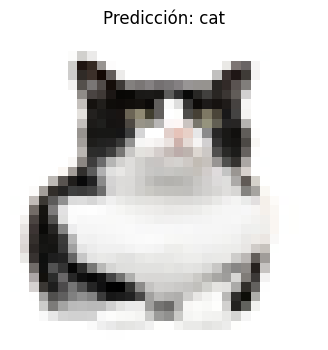

Predicciones completas para la imagen subida: [1.1225219e-04 1.8751854e-03 3.2029772e-04 8.5323465e-01 3.7399809e-06
 1.4173670e-01 1.3879776e-03 1.1392914e-03 1.3200557e-04 5.7861384e-05]
Clase predicha (índice): 3
Clase predicha (nombre): cat


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Cargar la imagen
img = Image.open(image_path)

# Redimensionar la imagen a 32x32 píxeles (tamaño de entrada del modelo CIFAR-10)
img = img.resize((32, 32))

# Convertir a array de NumPy y normalizar
img_array = image.img_to_array(img)
img_array = img_array / 255.0 # Normalizar a [0, 1]

# Expandir dimensiones para que coincida con el formato de entrada del modelo (batch_size, height, width, channels)
img_array = np.expand_dims(img_array, axis=0)

# Realizar la predicción
predictions = loaded_model.predict(img_array)
predicted_class_idx = np.argmax(predictions)
predicted_class_name = cifar10_class_names[predicted_class_idx]

# Mostrar la imagen y la predicción
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title(f"Predicción: {predicted_class_name}")
plt.axis('off')
plt.show()

print(f"Predicciones completas para la imagen subida: {predictions[0]}")
print(f"Clase predicha (índice): {predicted_class_idx}")
print(f"Clase predicha (nombre): {predicted_class_name}")